## Data Ingestion and Preprocessing

In [2]:
import os
import json
import shutil
import pandas as pd

In [3]:
# Read the JSONL file line by line and load it into a DataFrame
json_path = "D:\\sem3\\Image-Data\\photos.json"

photos_data = []
with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        photos_data.append(json.loads(line))  # Load each line as a JSON object

# Convert to Pandas DataFrame
photos_df = pd.DataFrame(photos_data)

# Display first few rows
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [4]:
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [5]:
# Subset 50,000 images randomly
subset_df = photos_df.sample(n=20000, random_state=42)  # Ensure reproducibility
subset_df.to_csv("subset")
# Show first few rows
subset_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 32568 to 129705
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   photo_id     20000 non-null  object
 1   business_id  20000 non-null  object
 2   caption      20000 non-null  object
 3   label        20000 non-null  object
dtypes: object(4)
memory usage: 781.2+ KB


In [6]:
import os
import shutil

# Define source and destination folders
photos_folder = "D:\\sem3\\Image-Data\\photos\\"  # Folder with all photos
subset_folder = "D:\\sem3\\Image-Data\\subset-photos\\"  # Folder for subset images

# Create the new folder if it doesn't exist
os.makedirs(subset_folder, exist_ok=True)

# Get a list of already moved images
existing_images = set(os.listdir(subset_folder))  # Set of already moved files

# Count how many images need to be moved
remaining_images = [photo_id for photo_id in subset_df["photo_id"] if f"{photo_id}.jpg" not in existing_images]

if not remaining_images:
    print(f"All subset images are already moved to {subset_folder}")
else:
    print(f"⚠ Moving {len(remaining_images)} images to {subset_folder}...")

    moved_count = 0
    for photo_id in remaining_images:
        src_path = os.path.join(photos_folder, f"{photo_id}.jpg")
        dest_path = os.path.join(subset_folder, f"{photo_id}.jpg")
        
        if os.path.exists(src_path):
            shutil.move(src_path, dest_path)
            moved_count += 1

    print(f"Moved {moved_count} new images to {subset_folder}")

All subset images are already moved to D:\sem3\Image-Data\subset-photos\


In [7]:
import cv2
import numpy as np
from tqdm import tqdm  # Progress bar
import matplotlib.pyplot as plt

In [8]:
def apply_intensity_threshold(image, threshold=128):
    """Apply binary intensity thresholding."""
    _, thresholded = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    return thresholded

def apply_histogram_equalization(image):
    """Apply histogram equalization for contrast enhancement."""
    return cv2.equalizeHist(image)

def apply_gaussian_blur(image, kernel_size=(5,5)):
    """Apply Gaussian blur to reduce noise."""
    return cv2.GaussianBlur(image, kernel_size, 0)

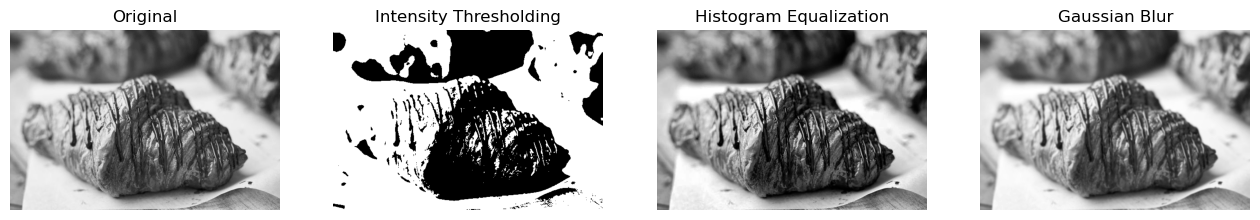

In [9]:
# Select a random image to test preprocessing
sample_image_id = subset_df.iloc[0]["photo_id"]
image_path = os.path.join("D:\\sem3\\Image-Data\\subset-photos\\", f"{sample_image_id}.jpg")

# Load image in grayscale
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Apply preprocessing
thresholded = apply_intensity_threshold(image)
equalized = apply_histogram_equalization(image)
blurred = apply_gaussian_blur(image)

# Show original and processed images
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
axs[0].imshow(image, cmap='gray')
axs[0].set_title("Original")

axs[1].imshow(thresholded, cmap='gray')
axs[1].set_title("Intensity Thresholding")

axs[2].imshow(equalized, cmap='gray')
axs[2].set_title("Histogram Equalization")

axs[3].imshow(blurred, cmap='gray')
axs[3].set_title("Gaussian Blur")

for ax in axs:
    ax.axis("off")

plt.show()

In [365]:
import os
from tqdm import tqdm

# Define processed image folder
processed_folder = "D:\\sem3\\Image-Data\\processed-photos\\"
os.makedirs(processed_folder, exist_ok=True)

# Check if preprocessing is already done
processed_images = set(os.listdir(processed_folder))  # Get list of already processed files

if len(processed_images) >= len(subset_df):  # Check if all images are already processed
    print(f" Preprocessing already completed! ({len(processed_images)} images available)")
else:
    print(f"Processing {len(subset_df) - len(processed_images)} new images...")

    # Process and save only unprocessed images
    for photo_id in tqdm(subset_df["photo_id"], desc="Processing Images"):
        input_path = os.path.join("D:\\sem3\\Image-Data\\subset-photos\\", f"{photo_id}.jpg")
        output_path = os.path.join(processed_folder, f"{photo_id}.jpg")

        if os.path.exists(input_path) and f"{photo_id}.jpg" not in processed_images:
            img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
            
            if img is None:  # Skip if image loading failed
                print(f"Skipping unreadable image: {input_path}")
                continue

            img = apply_intensity_threshold(img)  # Apply thresholding
            img = apply_histogram_equalization(img)  # Apply histogram equalization
            img = apply_gaussian_blur(img)  # Apply Gaussian blur

            cv2.imwrite(output_path, img)  # Save processed image

    print(f"Preprocessing completed! Processed images saved in: {processed_folder}")

Processing 6 new images...


Processing Images:  11%|█████▊                                                 | 2110/20000 [00:00<00:00, 20892.90it/s]

Skipping unreadable image: D:\sem3\Image-Data\subset-photos\1MOGQBWogR8oJr1WgERi9g.jpg


Processing Images:  48%|██████████████████████████▏                            | 9518/20000 [00:00<00:00, 16734.86it/s]

Skipping unreadable image: D:\sem3\Image-Data\subset-photos\pW1IPuTdLIUB61goirbXaA.jpg


Processing Images:  74%|████████████████████████████████████████▏             | 14878/20000 [00:00<00:00, 16590.97it/s]

Skipping unreadable image: D:\sem3\Image-Data\subset-photos\CBxmBYD_5CXIL_F-2PDqmA.jpg
Skipping unreadable image: D:\sem3\Image-Data\subset-photos\W94rrCn0O5K1lkfD26m4tw.jpg


Processing Images: 100%|██████████████████████████████████████████████████████| 20000/20000 [00:01<00:00, 17287.60it/s]


Skipping unreadable image: D:\sem3\Image-Data\subset-photos\7xcWPjcE4mxoQ1AjvvKJZg.jpg
Skipping unreadable image: D:\sem3\Image-Data\subset-photos\JZZ716oX6_MqH6L_MkWK-A.jpg
Preprocessing completed! Processed images saved in: D:\sem3\Image-Data\processed-photos\


## KNN Model with Cross-Validation, Confusion Matrix, and AUC

In [12]:
import numpy as np
import time
import torch
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # For saving model

In [13]:
import concurrent.futures
import os
import cv2

# Function to load and process a single image
def process_image(row):
    img_path = os.path.join("D:\\sem3\\Image-Data\\subset-photos\\", f"{row.photo_id}.jpg")  # Use dot notation
    
    if not os.path.exists(img_path):
        return None  # Skip missing files
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load preprocessed image
    if img is None:
        return None  # Skip unreadable images
    
    img = cv2.resize(img, (64, 64))  # Resize for uniformity
    return img.flatten(), row.label  # Use dot notation for label

# Use multi-threading to load images faster
X = []
y = []
with concurrent.futures.ThreadPoolExecutor() as executor:
    results = list(executor.map(process_image, subset_df.itertuples(index=False)))

# Filter out None values (failed loads)
filtered_results = [r for r in results if r is not None]
if filtered_results:  # Ensure there's data
    X, y = zip(*filtered_results)
    X = np.array(X)
    y = np.array(y)
else:
    X, y = np.array([]), np.array([])  # Handle empty case

print(f"Feature Matrix Shape: {X.shape}, Labels Shape: {y.shape}")

Feature Matrix Shape: (19994, 4096), Labels Shape: (19994,)


In [14]:
# Train-Test Split (80-20)
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Set: {X_train_k.shape}, Testing Set: {X_test_k.shape}")

Training Set: (15995, 4096), Testing Set: (3999, 4096)


In [15]:
# Define kNN classifier with optimal hyperparameters
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance', algorithm='auto', n_jobs=4)

# Cross-validation score
cv_scores = cross_val_score(knn, X_train_k, y_train_k, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f}")

Cross-Validation Accuracy: 0.5739


In [16]:
start_time = time.time()  # Start time tracking

# Train kNN on the full training set
knn.fit(X_train_k, y_train_k)

training_time_knn = time.time() - start_time  # Calculate training time
print(f"kNN Training Completed in {training_time_knn:.2f} seconds")

# Save trained model
joblib.dump(knn, "knn_model.pkl")

kNN Training Completed in 0.00 seconds


['knn_model.pkl']

In [17]:
# Predict on training set
y_pred_train_k = knn.predict(X_train_k)
y_prob_train_k = knn.predict_proba(X_train_k)  # Probabilities for AUC calculation

# Predict on test set
y_pred_test_k = knn.predict(X_test_k)
y_prob_test_k = knn.predict_proba(X_test_k)  # Probabilities for AUC calculation

# Compute accuracy and F1-score
accuracy_train_k = accuracy_score(y_train_k, y_pred_train_k)
f1_train_k = f1_score(y_train_k, y_pred_train_k, average="weighted")

accuracy_test_k = accuracy_score(y_test_k, y_pred_test_k)
f1_test_k = f1_score(y_test_k, y_pred_test_k, average="weighted")

print(f"kNN Training Accuracy: {accuracy_train_k:.4f}, F1 Score: {f1_train_k:.4f}")
print(f"kNN Testing Accuracy: {accuracy_test_k:.4f}, F1 Score: {f1_test_k:.4f}")

kNN Training Accuracy: 1.0000, F1 Score: 1.0000
kNN Testing Accuracy: 0.5804, F1 Score: 0.5428


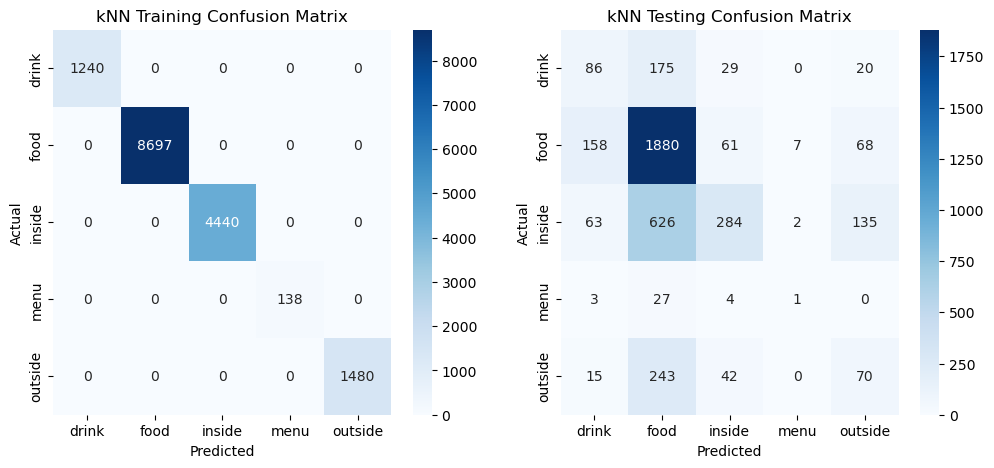

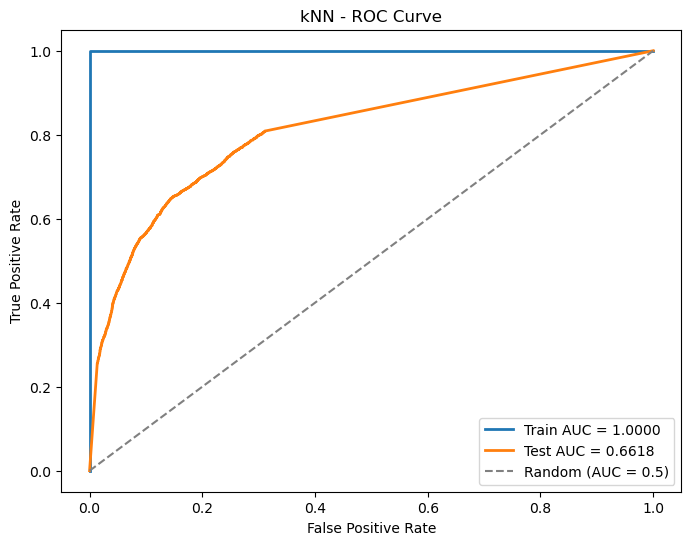

In [373]:
from sklearn.preprocessing import label_binarize

# Ensure labels are binarized for AUC computation
y_train_binarized_k = label_binarize(y_train_k, classes=np.unique(y_train_k))
y_test_binarized_k = label_binarize(y_test_k, classes=np.unique(y_test_k))

# Compute Confusion Matrices
conf_matrix_train_k = confusion_matrix(y_train_k, y_pred_train_k)
conf_matrix_test_k = confusion_matrix(y_test_k, y_pred_test_k)

# Plot Confusion Matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix_train_k, annot=True, fmt='d', cmap="Blues",
            xticklabels=np.unique(y_train_k), yticklabels=np.unique(y_train_k), ax=axs[0])
axs[0].set_title("kNN Training Confusion Matrix")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_test_k, annot=True, fmt='d', cmap="Blues",
            xticklabels=np.unique(y_test_k), yticklabels=np.unique(y_test_k), ax=axs[1])
axs[1].set_title("kNN Testing Confusion Matrix")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")

plt.show()

# Plot ROC Curves for kNN
if y_test_binarized_k.shape[1] > 1:
    fpr_train_k, tpr_train_k, _ = roc_curve(y_train_binarized_k.ravel(), y_prob_train_k.ravel())
    fpr_test_k, tpr_test_k, _ = roc_curve(y_test_binarized_k.ravel(), y_prob_test_k.ravel())

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train_k, tpr_train_k, label=f"Train AUC = {auc_train_k:.4f}", linewidth=2)
    plt.plot(fpr_test_k, tpr_test_k, label=f"Test AUC = {auc_test_k:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.5)")  # Dotted diagonal line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("kNN - ROC Curve")
    plt.legend()
    plt.show()

In [19]:
from sklearn.preprocessing import label_binarize

# Ensure labels are binarized for multiclass AUC calculation
y_train_binarized = label_binarize(y_train_k, classes=np.unique(y_train_k))
y_test_binarized = label_binarize(y_test_k, classes=np.unique(y_test_k))

# Compute AUC only if more than one class exists
if y_train_binarized.shape[1] > 1:
    auc_train_k = roc_auc_score(y_train_binarized, y_prob_train_k, multi_class="ovr")
else:
    auc_train_k = np.nan  # Set to NaN if not computable

if y_test_binarized.shape[1] > 1:
    auc_test_k = roc_auc_score(y_test_binarized, y_prob_test_k, multi_class="ovr")
else:
    auc_test_k = np.nan  # Set to NaN if not computable

print(f"kNN Training AUC Score: {auc_train_k}")
print(f"kNN Testing AUC Score: {auc_test_k}")

kNN Training AUC Score: 1.0
kNN Testing AUC Score: 0.6618405698085829


In [20]:
import pandas as pd

# Initialize DataFrame if not already done
if "results_df" not in locals():
    results_df = pd.DataFrame(columns=["Model", "Set", "Accuracy", "F1 Score", "AUC", "Training Time"])

# Create DataFrame for training and testing results
new_rows = pd.DataFrame([
    {
        "Model": "kNN",
        "Set": "Training",
        "Accuracy": accuracy_train_k,
        "F1 Score": f1_train_k,
        "AUC": auc_train_k if not np.isnan(auc_train_k) else "N/A",  # Handle NaN AUC
        "Training Time": training_time_knn
    },
    {
        "Model": "kNN",
        "Set": "Testing",
        "Accuracy": accuracy_test_k,
        "F1 Score": f1_test_k,
        "AUC": auc_test_k if not np.isnan(auc_test_k) else "N/A",  # Handle NaN AUC
        "Training Time": training_time_knn  # Same training time for reference
    }
])

# Remove empty or NaN rows and drop fully NaN columns before concatenation
new_rows = new_rows.dropna(how="all").dropna(axis=1, how="all")

# Concatenate only if new_rows has valid data
if not new_rows.empty:
    results_df = pd.concat([results_df, new_rows], ignore_index=True)

print("kNN Training & Testing Results Stored!")

kNN Training & Testing Results Stored!


C:\Users\chetn\AppData\Local\Temp\ipykernel_24176\3407656365.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_rows], ignore_index=True)


## SVM (without cross-validation)

In [22]:
# Copy train-test split from kNN for consistency
X_train_s, X_test_s, y_train_s, y_test_s = X_train_k, X_test_k, y_train_k, y_test_k
print(f"Training Set: {X_train_s.shape}, Testing Set: {X_test_s.shape}")

Training Set: (15995, 4096), Testing Set: (3999, 4096)


In [23]:
from sklearn.utils import resample

# Reduce training set to 5,000 samples (stratified sampling for class balance)
X_train_s_reduced, y_train_s_reduced = resample(X_train_s, y_train_s, n_samples=5000, stratify=y_train_s, random_state=42)

print(f"New SVM Training Set: {X_train_s_reduced.shape}")

New SVM Training Set: (5000, 4096)


In [24]:
from sklearn.svm import SVC

# Define SVM model (no cross-validation)
# Adjust cache size based on system memory (1000MB default, increase if needed)
svm_model = SVC(kernel="rbf", probability=True, random_state=42, cache_size=2000, gamma="scale")

# Train the model and measure training time
start_time = time.time()
svm_model.fit(X_train_s_reduced, y_train_s_reduced)
training_time_svm = time.time() - start_time

# Save trained SVM model
svm_model_path = "svm_model.pkl"
joblib.dump(svm_model, svm_model_path)

print(f"SVM Training Completed in {training_time_svm:.2f} seconds")
print(f"SVM Model saved as {svm_model_path}")

SVM Training Completed in 315.14 seconds
SVM Model saved as svm_model.pkl


In [28]:
# Predict on training set (use reduced training set)
y_pred_train_s = svm_model.predict(X_train_s_reduced)
y_prob_train_s = svm_model.predict_proba(X_train_s_reduced)

# Predict on test set (remains the same)
y_pred_test_s = svm_model.predict(X_test_s)
y_prob_test_s = svm_model.predict_proba(X_test_s)

# Compute accuracy and F1-score
accuracy_train_s = accuracy_score(y_train_s_reduced, y_pred_train_s)
f1_train_s = f1_score(y_train_s_reduced, y_pred_train_s, average="weighted")

accuracy_test_s = accuracy_score(y_test_s, y_pred_test_s)
f1_test_s = f1_score(y_test_s, y_pred_test_s, average="weighted")

print(f"SVM Training Accuracy: {accuracy_train_s:.4f}, F1 Score: {f1_train_s:.4f}")
print(f"SVM Testing Accuracy: {accuracy_test_s:.4f}, F1 Score: {f1_test_s:.4f}")

SVM Training Accuracy: 0.8464, F1 Score: 0.8300
SVM Testing Accuracy: 0.6859, F1 Score: 0.6433


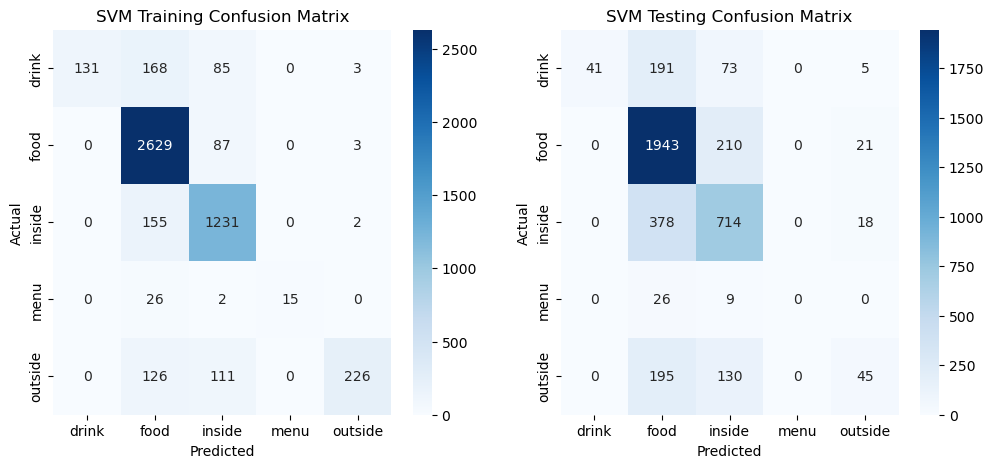

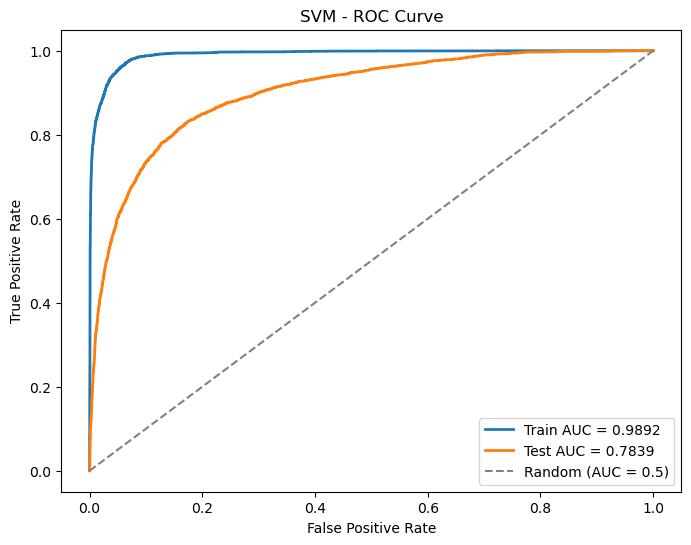

In [371]:
# Compute Confusion Matrices
conf_matrix_train_s = confusion_matrix(y_train_s_reduced, y_pred_train_s)
conf_matrix_test_s = confusion_matrix(y_test_s, y_pred_test_s)

# Plot Confusion Matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix_train_s, annot=True, fmt='d', cmap="Blues",
            xticklabels=np.unique(y_train_s_reduced), yticklabels=np.unique(y_train_s_reduced), ax=axs[0])
axs[0].set_title("SVM Training Confusion Matrix")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_test_s, annot=True, fmt='d', cmap="Blues",
            xticklabels=np.unique(y_test_s), yticklabels=np.unique(y_test_s), ax=axs[1])
axs[1].set_title("SVM Testing Confusion Matrix")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")

plt.show()

# Plot ROC Curves for SVM
if y_test_binarized_s.shape[1] > 1:
    fpr_train_s, tpr_train_s, _ = roc_curve(y_train_binarized_s.ravel(), y_prob_train_s.ravel())
    fpr_test_s, tpr_test_s, _ = roc_curve(y_test_binarized_s.ravel(), y_prob_test_s.ravel())

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train_s, tpr_train_s, label=f"Train AUC = {auc_train_s:.4f}", linewidth=2)
    plt.plot(fpr_test_s, tpr_test_s, label=f"Test AUC = {auc_test_s:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.5)")  # Dotted diagonal line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("SVM - ROC Curve")
    plt.legend()
    plt.show()

In [32]:
# Ensure labels are binarized
y_train_binarized_s = label_binarize(y_train_s_reduced, classes=np.unique(y_train_s_reduced))
y_test_binarized_s = label_binarize(y_test_s, classes=np.unique(y_test_s))

# Compute AUC only if more than one class exists
if y_train_binarized_s.shape[1] > 1:
    auc_train_s = roc_auc_score(y_train_binarized_s, y_prob_train_s, multi_class="ovr")
else:
    auc_train_s = np.nan  # Set to NaN if not computable

if y_test_binarized_s.shape[1] > 1:
    auc_test_s = roc_auc_score(y_test_binarized_s, y_prob_test_s, multi_class="ovr")
else:
    auc_test_s = np.nan  # Set to NaN if not computable

print(f"SVM Training AUC Score: {auc_train_s}")
print(f"SVM Testing AUC Score: {auc_test_s}")

SVM Training AUC Score: 0.989228007719046
SVM Testing AUC Score: 0.7838529900532354


In [34]:
# Create DataFrame for training and testing results
new_rows = pd.DataFrame([
    {
        "Model": "SVM",
        "Set": "Training",
        "Accuracy": accuracy_train_s,
        "F1 Score": f1_train_s,
        "AUC": auc_train_s if not np.isnan(auc_train_s) else "N/A",
        "Training Time": training_time_svm
    },
    {
        "Model": "SVM",
        "Set": "Testing",
        "Accuracy": accuracy_test_s,
        "F1 Score": f1_test_s,
        "AUC": auc_test_s if not np.isnan(auc_test_s) else "N/A",
        "Training Time": training_time_svm
    }
])

# Remove empty or NaN rows and drop fully NaN columns before concatenation
new_rows = new_rows.dropna(how="all").dropna(axis=1, how="all")

# Concatenate only if new_rows has valid data
if not new_rows.empty:
    results_df = pd.concat([results_df, new_rows], ignore_index=True)

print("SVM Training & Testing Results Stored!")

SVM Training & Testing Results Stored!


## Deep Neural Network (DNN) with Cross Validation

In [38]:
# Use the same split as before
X_train_d, X_test_d, y_train_d, y_test_d = X_train_k, X_test_k, y_train_k, y_test_k

print(f"Training Set: {X_train_d.shape}, Testing Set: {X_test_d.shape}")

Training Set: (15995, 4096), Testing Set: (3999, 4096)


In [121]:
from sklearn.preprocessing import LabelEncoder

# Encode labels as integers
label_encoder = LabelEncoder()
y_train_d_encoded = label_encoder.fit_transform(y_train_d)
y_test_d_encoded = label_encoder.transform(y_test_d)

# Convert NumPy arrays to PyTorch tensors & move to device (GPU if available)
X_train_d_tensor = torch.tensor(X_train_d, dtype=torch.float32).to(device) / 255.0  # Normalize
y_train_d_tensor = torch.tensor(y_train_d_encoded, dtype=torch.long).to(device)

X_test_d_tensor = torch.tensor(X_test_d, dtype=torch.float32).to(device) / 255.0  # Normalize
y_test_d_tensor = torch.tensor(y_test_d_encoded, dtype=torch.long).to(device)

# Create PyTorch Dataset
train_dataset = TensorDataset(X_train_d_tensor, y_train_d_tensor)
test_dataset = TensorDataset(X_test_d_tensor, y_test_d_tensor)

# Create DataLoader for mini-batch training
batch_size = 64  # Adjust as needed
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoader Ready: {len(train_loader)} train batches, {len(test_loader)} test batches")

DataLoader Ready: 250 train batches, 63 test batches


In [130]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Define Stratified K-Fold Cross-Validation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store results for each fold
fold_train_accuracies = []
fold_test_accuracies = []
fold_train_losses = []
fold_test_losses = []

# Convert tensors back to NumPy for CV processing
X_train_np = X_train_d_tensor.cpu().numpy()
y_train_np = y_train_d_tensor.cpu().numpy()

# Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np)):
    print(f"\nTraining Fold {fold+1}/{k_folds}")

    # Split data
    X_train_fold = torch.tensor(X_train_np[train_idx], dtype=torch.float32).to(device)
    y_train_fold = torch.tensor(y_train_np[train_idx], dtype=torch.long).to(device)
    X_val_fold = torch.tensor(X_train_np[val_idx], dtype=torch.float32).to(device)
    y_val_fold = torch.tensor(y_train_np[val_idx], dtype=torch.long).to(device)

    # Create DataLoader
    train_fold_dataset = TensorDataset(X_train_fold, y_train_fold)
    val_fold_dataset = TensorDataset(X_val_fold, y_val_fold)

    train_fold_loader = DataLoader(train_fold_dataset, batch_size=batch_size, shuffle=True)
    val_fold_loader = DataLoader(val_fold_dataset, batch_size=batch_size, shuffle=False)

    # Initialize Model (New model for each fold)
    dnn_model_cv = ImprovedDNN(num_classes=len(np.unique(y_train_d))).to(device)

    # Define Loss Function & Optimizer with L2 Regularization
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(dnn_model_cv.parameters(), lr=0.0005, weight_decay=0.0005)

    # Train for a few epochs on each fold
    num_epochs_cv = 10  # Reduce epochs per fold for efficiency
    best_val_loss = float("inf")

    for epoch in range(num_epochs_cv):
        dnn_model_cv.train()
        train_loss = 0.0
        correct_train, total_train = 0, 0

        for images, labels in train_fold_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = dnn_model_cv(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_accuracy = 100 * correct_train / total_train
        fold_train_accuracies.append(train_accuracy)
        fold_train_losses.append(train_loss / len(train_fold_loader))

        # Validate on the validation fold
        dnn_model_cv.eval()
        val_loss = 0.0
        correct_val, total_val = 0, 0

        with torch.no_grad():
            for images, labels in val_fold_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = dnn_model_cv(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_accuracy = 100 * correct_val / total_val
        fold_test_accuracies.append(val_accuracy)
        fold_test_losses.append(val_loss / len(val_fold_loader))

        print(f"Epoch [{epoch+1}/{num_epochs_cv}] "
              f"Train Loss: {fold_train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}% | "
              f"Val Loss: {fold_test_losses[-1]:.4f}, Val Acc: {val_accuracy:.2f}%")

        # Save best model for this fold
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = dnn_model_cv.state_dict()

    # Load best model state after CV training
    dnn_model_cv.load_state_dict(best_model_state)

# Compute Average Performance Across All Folds
mean_train_acc = np.mean(fold_train_accuracies)
mean_test_acc = np.mean(fold_test_accuracies)
mean_train_loss = np.mean(fold_train_losses)
mean_test_loss = np.mean(fold_test_losses)

print("\nFinal Cross-Validation Results (Averaged over Folds)")
print(f"Train Accuracy: {mean_train_acc:.2f}%, Train Loss: {mean_train_loss:.4f}")
print(f"Validation Accuracy: {mean_test_acc:.2f}%, Validation Loss: {mean_test_loss:.4f}")


Training Fold 1/5
Epoch [1/10] Train Loss: 1.0225, Train Acc: 63.57% | Val Loss: 0.9467, Val Acc: 65.27%
Epoch [2/10] Train Loss: 0.9097, Train Acc: 66.98% | Val Loss: 0.9135, Val Acc: 66.65%
Epoch [3/10] Train Loss: 0.8798, Train Acc: 67.46% | Val Loss: 0.9440, Val Acc: 66.68%
Epoch [4/10] Train Loss: 0.8461, Train Acc: 69.05% | Val Loss: 0.9125, Val Acc: 66.49%
Epoch [5/10] Train Loss: 0.8195, Train Acc: 69.87% | Val Loss: 0.9349, Val Acc: 66.68%
Epoch [6/10] Train Loss: 0.7926, Train Acc: 70.95% | Val Loss: 0.9432, Val Acc: 65.68%
Epoch [7/10] Train Loss: 0.7654, Train Acc: 71.41% | Val Loss: 0.9270, Val Acc: 66.99%
Epoch [8/10] Train Loss: 0.7337, Train Acc: 72.55% | Val Loss: 0.9604, Val Acc: 66.68%
Epoch [9/10] Train Loss: 0.7139, Train Acc: 73.84% | Val Loss: 1.0426, Val Acc: 66.58%
Epoch [10/10] Train Loss: 0.6840, Train Acc: 74.84% | Val Loss: 0.9280, Val Acc: 65.24%

Training Fold 2/5
Epoch [1/10] Train Loss: 1.0026, Train Acc: 63.57% | Val Loss: 0.9239, Val Acc: 65.90%
Epoc

### Iteration 1

In [132]:
import torch
import torch.nn as nn
import torch.optim as optim

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the DNN Model
class DNNClassifier(nn.Module):
    def __init__(self, input_size=4096, hidden_sizes=[1024, 512, 256], num_classes=10, dropout=0.3):
        super(DNNClassifier, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.BatchNorm1d(hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.BatchNorm1d(hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_sizes[1], hidden_sizes[2]),
            nn.BatchNorm1d(hidden_sizes[2]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_sizes[2], num_classes),  # Output Layer
        )
        
    def forward(self, x):
        return self.model(x)

# Instantiate model and move to GPU if available
num_classes = len(np.unique(y_train_d))  # Automatically get number of classes
dnn_model = DNNClassifier(num_classes=num_classes).to(device)
print(dnn_model)

Using device: cuda
DNNClassifier(
  (model): Sequential(
    (0): Linear(in_features=4096, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=5, bias=True)
  )
)


In [133]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dnn_model.parameters(), lr=0.001)

# Training Loop
num_epochs = 10  # Adjust based on performance
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    dnn_model.train()  # Set model to training mode
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = dnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_accuracy = 100 * correct_train / total_train
    train_losses.append(running_loss / len(train_loader))

    # Evaluate on test set
    dnn_model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = dnn_model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)

    test_accuracy = 100 * correct_test / total_test
    test_losses.append(test_loss / len(test_loader))

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}% | "
          f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_accuracy:.2f}%")

print("Training Complete!")

Epoch [1/10] Train Loss: 0.9778, Train Acc: 64.40% | Test Loss: 0.9308, Test Acc: 64.93%
Epoch [2/10] Train Loss: 0.9060, Train Acc: 66.91% | Test Loss: 0.9270, Test Acc: 66.02%
Epoch [3/10] Train Loss: 0.8599, Train Acc: 68.37% | Test Loss: 0.9489, Test Acc: 63.55%
Epoch [4/10] Train Loss: 0.8109, Train Acc: 70.02% | Test Loss: 0.9838, Test Acc: 66.24%
Epoch [5/10] Train Loss: 0.7674, Train Acc: 72.09% | Test Loss: 1.0394, Test Acc: 59.99%
Epoch [6/10] Train Loss: 0.7063, Train Acc: 74.22% | Test Loss: 0.9530, Test Acc: 64.61%
Epoch [7/10] Train Loss: 0.6601, Train Acc: 75.84% | Test Loss: 1.0020, Test Acc: 60.93%
Epoch [8/10] Train Loss: 0.6014, Train Acc: 78.44% | Test Loss: 0.9937, Test Acc: 66.49%
Epoch [9/10] Train Loss: 0.5559, Train Acc: 79.78% | Test Loss: 1.1925, Test Acc: 66.86%
Epoch [10/10] Train Loss: 0.5085, Train Acc: 81.75% | Test Loss: 1.0365, Test Acc: 66.74%
Training Complete!


### Iteration 2

In [139]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define Improved DNN Model (Version 2)
class ImprovedDNN(nn.Module):
    def __init__(self, input_size=4096, hidden_sizes=[1024, 512, 256], num_classes=10, dropout=0.4):
        super(ImprovedDNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.BatchNorm1d(hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(dropout),  

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.BatchNorm1d(hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(dropout),  

            nn.Linear(hidden_sizes[1], hidden_sizes[2]),
            nn.BatchNorm1d(hidden_sizes[2]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_sizes[2], num_classes),  
        )
        
    def forward(self, x):
        return self.model(x)

# Instantiate Model & Move to GPU
dnn_model2 = ImprovedDNN(num_classes=len(np.unique(y_train_d))).to(device)

print(dnn_model2)

ImprovedDNN(
  (model): Sequential(
    (0): Linear(in_features=4096, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=256, out_features=5, bias=True)
  )
)


In [141]:
# Define Loss Function & Optimizer with L2 Regularization
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dnn_model2.parameters(), lr=0.0005, weight_decay=0.0005)  # Lower LR + L2 Regularization

# Learning Rate Scheduler (Fix: Remove verbose, manually print LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

num_epochs = 20  # Increase epochs for better learning
best_test_loss = float('inf')
patience = 3  # Stop training if test loss doesn't improve for 3 epochs
no_improve_epochs = 0

train_losses, test_losses = [], []

for epoch in range(num_epochs):
    dnn_model2.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = dnn_model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_accuracy = 100 * correct_train / total_train
    train_losses.append(running_loss / len(train_loader))

    # Evaluate on test set
    dnn_model2.eval()
    test_loss = 0.0
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = dnn_model2(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)

    test_accuracy = 100 * correct_test / total_test
    test_losses.append(test_loss / len(test_loader))

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}% | "
          f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_accuracy:.2f}%")

    # Apply Learning Rate Scheduler
    scheduler.step(test_losses[-1])

    # Early Stopping
    if test_losses[-1] < best_test_loss:
        best_test_loss = test_losses[-1]
        no_improve_epochs = 0  # Reset counter
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= patience:
            print("Early stopping activated (No improvement for 3 epochs)")
            break

print("Training Complete!")

Epoch [1/20] Train Loss: 1.0183, Train Acc: 63.20% | Test Loss: 0.9304, Test Acc: 65.93%
Epoch [2/20] Train Loss: 0.9182, Train Acc: 66.53% | Test Loss: 0.9028, Test Acc: 65.74%
Epoch [3/20] Train Loss: 0.8854, Train Acc: 67.90% | Test Loss: 0.9785, Test Acc: 62.83%
Epoch [4/20] Train Loss: 0.8510, Train Acc: 69.01% | Test Loss: 0.9004, Test Acc: 66.68%
Epoch [5/20] Train Loss: 0.8269, Train Acc: 69.90% | Test Loss: 0.9659, Test Acc: 66.33%
Epoch [6/20] Train Loss: 0.7947, Train Acc: 71.35% | Test Loss: 0.8975, Test Acc: 67.36%
Epoch [7/20] Train Loss: 0.7660, Train Acc: 72.05% | Test Loss: 1.0346, Test Acc: 61.05%
Epoch [8/20] Train Loss: 0.7452, Train Acc: 73.16% | Test Loss: 0.9584, Test Acc: 66.05%
Epoch [9/20] Train Loss: 0.7154, Train Acc: 73.79% | Test Loss: 0.9378, Test Acc: 63.64%
Early stopping activated (No improvement for 3 epochs)
Training Complete!


### Iteration 3

In [176]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CyclicLR

# Define Strong Regularized DNN Model (Iteration 3)
class OptimizedDNN(nn.Module):
    def __init__(self, input_size=4096, hidden_sizes=[2048, 1024, 512, 256, 128], num_classes=10, dropout=0.6):
        super(OptimizedDNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.BatchNorm1d(hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(dropout),  

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.BatchNorm1d(hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(dropout),  

            nn.Linear(hidden_sizes[1], hidden_sizes[2]),
            nn.BatchNorm1d(hidden_sizes[2]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_sizes[2], hidden_sizes[3]),
            nn.BatchNorm1d(hidden_sizes[3]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_sizes[3], hidden_sizes[4]),
            nn.BatchNorm1d(hidden_sizes[4]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_sizes[4], num_classes),  
        )
        
    def forward(self, x):
        return self.model(x)

# Instantiate Model & Move to GPU
dnn_model3 = OptimizedDNN(num_classes=len(np.unique(y_train_d))).to(device)

print(dnn_model3)

OptimizedDNN(
  (model): Sequential(
    (0): Linear(in_features=4096, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=2048, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
    (8): Linear(in_features=1024, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.6, inplace=False)
    (12): Linear(in_features=512, out_features=256, bias=True)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.6, inplace=False)
    (16): Linear(in_features=256, out_features=128, bias=True)
    (17): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=

In [178]:
import time

# Define Loss Function & Optimizer with Strong Regularization
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dnn_model3.parameters(), lr=0.0003, weight_decay=0.0007)  # Lower LR + L2 Regularization

# Learning Rate Scheduler (Cyclic LR to boost training speed & stability)
scheduler = CyclicLR(optimizer, base_lr=0.0001, max_lr=0.001, step_size_up=5, mode="triangular2")

start_time = time.time()
num_epochs = 50  # Increased epochs to allow strong generalization
best_test_loss = float('inf')
patience = 5  # Stop training if test loss doesn't improve for 5 epochs
no_improve_epochs = 0

train_losses, test_losses = [], []

for epoch in range(num_epochs):
    dnn_model3.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = dnn_model3(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()  # Cyclic LR updates

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_accuracy = 100 * correct_train / total_train
    train_losses.append(running_loss / len(train_loader))

    # Evaluate on test set
    dnn_model3.eval()
    test_loss = 0.0
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = dnn_model3(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)

    test_accuracy = 100 * correct_test / total_test
    test_losses.append(test_loss / len(test_loader))

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}% | "
          f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_accuracy:.2f}%")

    # # Apply Early Stopping
    if test_losses[-1] < best_test_loss:
        best_test_loss = test_losses[-1]
        no_improve_epochs = 0  # Reset counter
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= patience:
            print("Early stopping activated (No improvement for 5 epochs)")
            break

# End Timer & Compute Training Time
end_time = time.time()
training_time_dnn3 = round(end_time - start_time, 2)  # Time in seconds

print(f"Training Complete! Total Training Time: {training_time_dnn3} seconds")

Epoch [1/50] Train Loss: 1.3496, Train Acc: 48.86% | Test Loss: 1.1154, Test Acc: 64.18%
Epoch [2/50] Train Loss: 1.1016, Train Acc: 62.05% | Test Loss: 0.9950, Test Acc: 64.96%
Epoch [3/50] Train Loss: 1.0478, Train Acc: 64.00% | Test Loss: 0.9633, Test Acc: 65.30%
Epoch [4/50] Train Loss: 1.0139, Train Acc: 64.44% | Test Loss: 0.9370, Test Acc: 65.71%
Epoch [5/50] Train Loss: 0.9888, Train Acc: 65.16% | Test Loss: 0.9259, Test Acc: 65.93%
Epoch [6/50] Train Loss: 0.9731, Train Acc: 65.66% | Test Loss: 0.9218, Test Acc: 66.43%
Epoch [7/50] Train Loss: 0.9528, Train Acc: 66.71% | Test Loss: 0.9118, Test Acc: 66.77%
Epoch [8/50] Train Loss: 0.9376, Train Acc: 66.92% | Test Loss: 0.9070, Test Acc: 66.71%
Epoch [9/50] Train Loss: 0.9129, Train Acc: 67.63% | Test Loss: 0.8989, Test Acc: 66.86%
Epoch [10/50] Train Loss: 0.8985, Train Acc: 68.82% | Test Loss: 0.8999, Test Acc: 66.30%
Epoch [11/50] Train Loss: 0.8805, Train Acc: 69.42% | Test Loss: 0.9294, Test Acc: 67.21%
Epoch [12/50] Train

### Performance

In [355]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Function to evaluate model
def evaluate_dnn(dnn_model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, title):
    dnn_model.eval()  # Set model to evaluation mode
    
    with torch.no_grad():
        y_train_pred = dnn_model(X_train_tensor).cpu()
        y_test_pred = dnn_model(X_test_tensor).cpu()
    
    # Convert logits to probabilities
    y_train_prob = torch.softmax(y_train_pred, dim=1).numpy()
    y_test_prob = torch.softmax(y_test_pred, dim=1).numpy()
    
    # Get predicted labels
    y_train_pred_labels = torch.argmax(y_train_pred, dim=1).numpy()
    y_test_pred_labels = torch.argmax(y_test_pred, dim=1).numpy()

    # Compute metrics
    accuracy_train = accuracy_score(y_train_tensor.cpu(), y_train_pred_labels)
    accuracy_test = accuracy_score(y_test_tensor.cpu(), y_test_pred_labels)
    f1_train = f1_score(y_train_tensor.cpu(), y_train_pred_labels, average="weighted")
    f1_test = f1_score(y_test_tensor.cpu(), y_test_pred_labels, average="weighted")

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train_tensor.cpu(), y_train_pred_labels)
    conf_matrix_test = confusion_matrix(y_test_tensor.cpu(), y_test_pred_labels)

    # Compute AUC
    y_train_bin = label_binarize(y_train_tensor.cpu(), classes=np.unique(y_train_tensor.cpu()))
    y_test_bin = label_binarize(y_test_tensor.cpu(), classes=np.unique(y_test_tensor.cpu()))

    auc_train = roc_auc_score(y_train_bin, y_train_prob, multi_class="ovr") if y_train_bin.shape[1] > 1 else np.nan
    auc_test = roc_auc_score(y_test_bin, y_test_prob, multi_class="ovr") if y_test_bin.shape[1] > 1 else np.nan

    # Print metrics
    print(f"\n**{title} Evaluation**")
    print(f"Train Accuracy: {accuracy_train:.4f}, Train F1-Score: {f1_train:.4f}, Train AUC: {auc_train:.4f}")
    print(f"Test Accuracy: {accuracy_test:.4f}, Test F1-Score: {f1_test:.4f}, Test AUC: {auc_test:.4f}")

    # Plot confusion matrices
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap="Blues",
                xticklabels=np.unique(y_train_tensor.cpu()), 
                yticklabels=np.unique(y_train_tensor.cpu()), ax=axs[0])
    axs[0].set_title(f"{title} - Training Confusion Matrix")
    axs[0].set_xlabel("Predicted")
    axs[0].set_ylabel("Actual")

    sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap="Blues",
                xticklabels=np.unique(y_test_tensor.cpu()), 
                yticklabels=np.unique(y_test_tensor.cpu()), ax=axs[1])
    axs[1].set_title(f"{title} - Testing Confusion Matrix")
    axs[1].set_xlabel("Predicted")
    axs[1].set_ylabel("Actual")

    plt.show()

    # Plot ROC Curves for Train and Test
    if y_train_bin.shape[1] > 1 and y_test_bin.shape[1] > 1:
        fpr_train, tpr_train, _ = roc_curve(y_train_bin.ravel(), y_train_prob.ravel())
        fpr_test, tpr_test, _ = roc_curve(y_test_bin.ravel(), y_test_prob.ravel())

        plt.figure(figsize=(8, 6))
        plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.4f}", linewidth=2)
        plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.4f}", linewidth=2)
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.5)")  # Dotted diagonal line
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{title} - ROC Curve")
        plt.legend()
        plt.show()


**DNN Iteration 1 Evaluation**
Train Accuracy: 0.8353, Train F1-Score: 0.8233, Train AUC: 0.9430
Test Accuracy: 0.6672, Test F1-Score: 0.6451, Test AUC: 0.7860


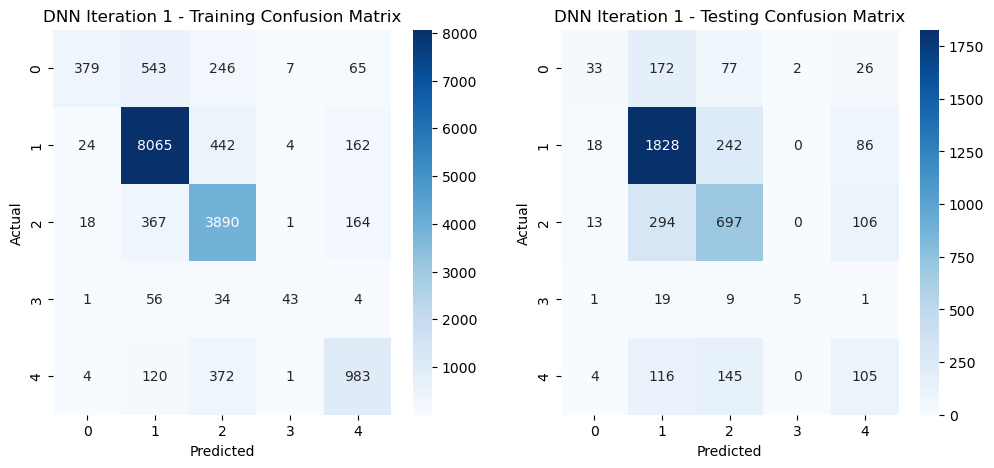

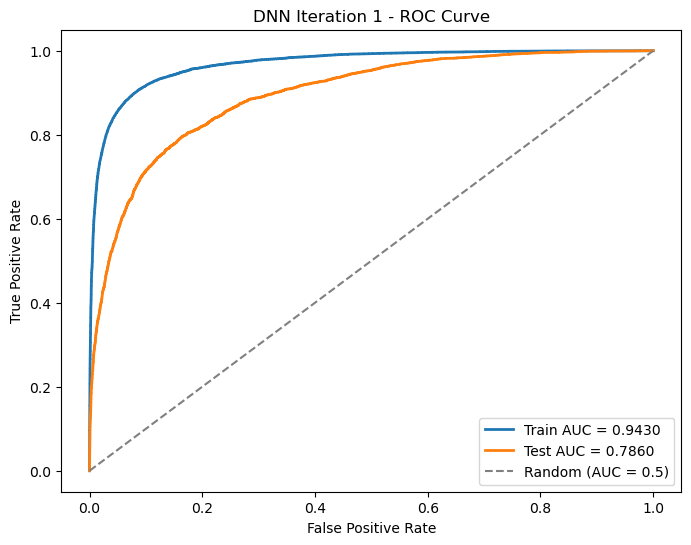

In [357]:
# Evaluate Iteration 1 (DNN Model 1)
evaluate_dnn(dnn_model, X_train_d_tensor, y_train_d_tensor, X_test_d_tensor, y_test_d_tensor, title="DNN Iteration 1")


**DNN Iteration 2 Evaluation**
Train Accuracy: 0.7410, Train F1-Score: 0.7300, Train AUC: 0.8942
Test Accuracy: 0.6464, Test F1-Score: 0.6362, Test AUC: 0.7915


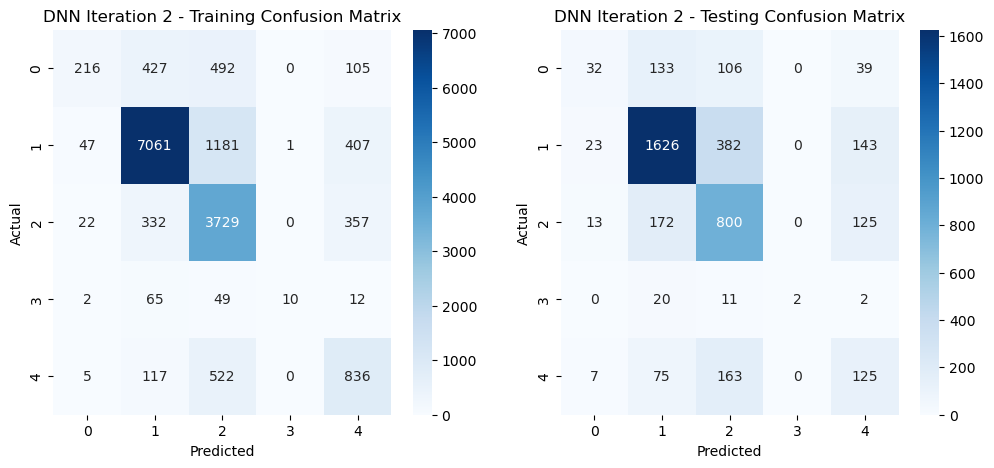

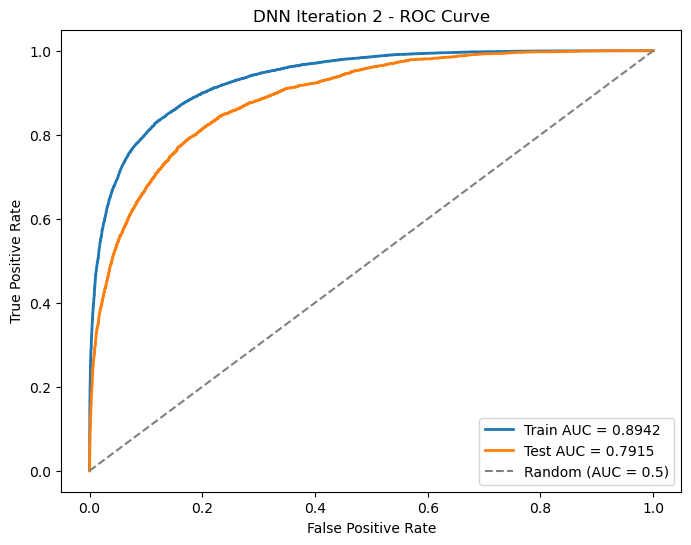

In [359]:
# Evaluate Iteration 2 (DNN Model 2)
evaluate_dnn(dnn_model2, X_train_d_tensor, y_train_d_tensor, X_test_d_tensor, y_test_d_tensor, title="DNN Iteration 2")


**DNN Iteration 3 Evaluation**
Train Accuracy: 0.6834, Train F1-Score: 0.6567, Train AUC: 0.8349
Test Accuracy: 0.6269, Test F1-Score: 0.6023, Test AUC: 0.7641


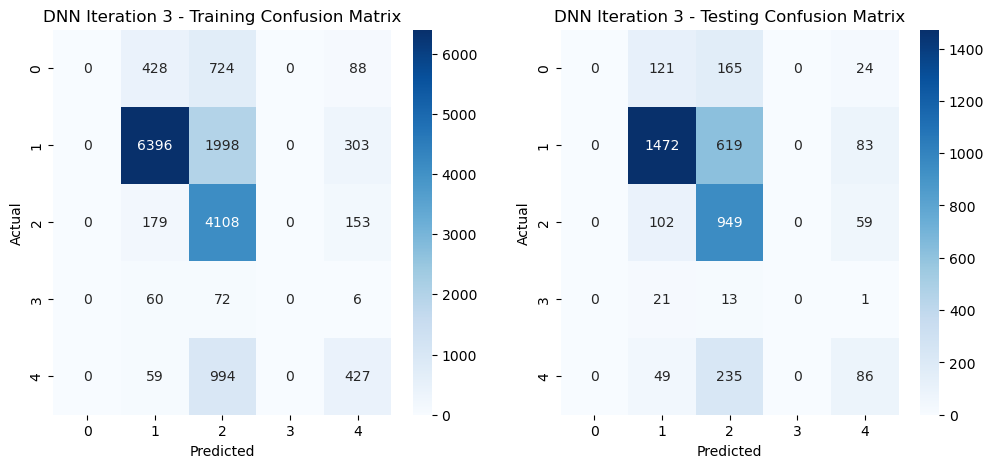

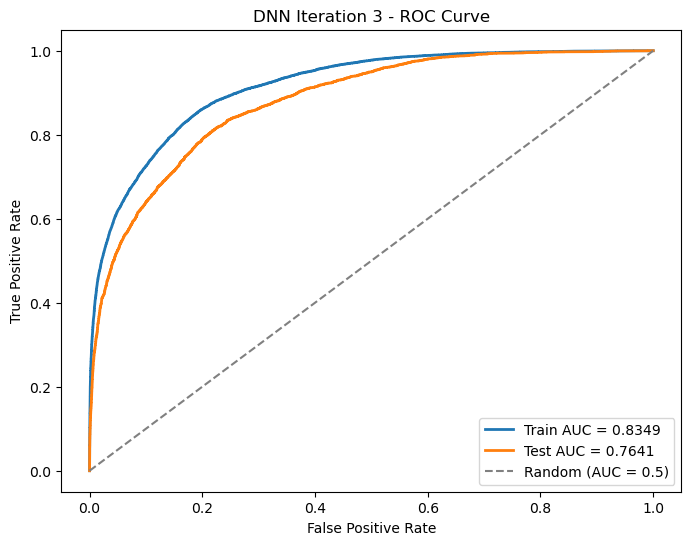

In [361]:
# Evaluate Iteration 3 (DNN Model 3)
evaluate_dnn(dnn_model3, X_train_d_tensor, y_train_d_tensor, X_test_d_tensor, y_test_d_tensor, title="DNN Iteration 3")

In [197]:
# Ensure `results_df` exists
if "results_df" not in locals():
    results_df = pd.DataFrame(columns=["Model", "Set", "Accuracy", "F1 Score", "AUC", "Training Time"])

# Evaluate Iteration 3 (Final Optimized Model)
dnn_model3.eval()

with torch.no_grad():
    y_train_pred = dnn_model3(X_train_d_tensor).cpu()
    y_test_pred = dnn_model3(X_test_d_tensor).cpu()

# Convert logits to probabilities
y_train_prob = torch.softmax(y_train_pred, dim=1).numpy()
y_test_prob = torch.softmax(y_test_pred, dim=1).numpy()

# Get predicted labels
y_train_pred_labels = torch.argmax(y_train_pred, dim=1).numpy()
y_test_pred_labels = torch.argmax(y_test_pred, dim=1).numpy()

# Compute Accuracy and F1-Score
accuracy_train_dnn = accuracy_score(y_train_d_tensor.cpu(), y_train_pred_labels)
accuracy_test_dnn = accuracy_score(y_test_d_tensor.cpu(), y_test_pred_labels)

f1_train_dnn = f1_score(y_train_d_tensor.cpu(), y_train_pred_labels, average="weighted")
f1_test_dnn = f1_score(y_test_d_tensor.cpu(), y_test_pred_labels, average="weighted")

# Compute Confusion Matrices
conf_matrix_train_dnn = confusion_matrix(y_train_d_tensor.cpu(), y_train_pred_labels)
conf_matrix_test_dnn = confusion_matrix(y_test_d_tensor.cpu(), y_test_pred_labels)

# Store confusion matrices for final visualization
confusion_matrices["DNN_Train"] = conf_matrix_train_dnn
confusion_matrices["DNN_Test"] = conf_matrix_test_dnn

# Compute AUC
y_train_bin = label_binarize(y_train_d_tensor.cpu(), classes=np.unique(y_train_d_tensor.cpu()))
y_test_bin = label_binarize(y_test_d_tensor.cpu(), classes=np.unique(y_test_d_tensor.cpu()))

auc_train_dnn = roc_auc_score(y_train_bin, y_train_prob, multi_class="ovr") if y_train_bin.shape[1] > 1 else np.nan
auc_test_dnn = roc_auc_score(y_test_bin, y_test_prob, multi_class="ovr") if y_test_bin.shape[1] > 1 else np.nan

# Append results to DataFrame
new_results = pd.DataFrame([
    {"Model": "DNN Iteration 3", "Set": "Training", "Accuracy": accuracy_train_dnn, "F1 Score": f1_train_dnn, "AUC": auc_train_dnn, "Training Time": training_time_dnn3},
    {"Model": "DNN Iteration 3", "Set": "Testing", "Accuracy": accuracy_test_dnn, "F1 Score": f1_test_dnn, "AUC": auc_test_dnn, "Training Time": num_epochs}
])

results_df = pd.concat([results_df, new_results], ignore_index=True)

print("DNN Training & Testing Results Stored ")

DNN Training & Testing Results Stored 


In [226]:
# Save Model Weights in CWD
torch.save(dnn_model3.state_dict(), "dnn_model3.pth")
print("Model saved as `dnn_model3.pth`")

# Save Label Encoder in CWD
joblib.dump(label_encoder, "label_encoder_dnn.pkl")
print("Label Encoder saved as `label_encoder_dnn.pkl`")

Model saved as `dnn_model3.pth`
Label Encoder saved as `label_encoder_dnn.pkl`


## Convolutional Neural Netwok (CNN) with cross validation

In [214]:
# Use the same split as before
X_train_c, X_test_c, y_train_c, y_test_c = X_train_k, X_test_k, y_train_k, y_test_k

print(f"Training Set: {X_train_d.shape}, Testing Set: {X_test_d.shape}")

Training Set: (15995, 4096), Testing Set: (3999, 4096)


In [223]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder

# Convert string labels to integers
label_encoder = LabelEncoder()
y_train_c_int = label_encoder.fit_transform(y_train_c)
y_test_c_int = label_encoder.transform(y_test_c)

# Convert NumPy arrays to PyTorch tensors & move to device
X_train_c_tensor = torch.tensor(X_train_c, dtype=torch.float32).to(device) / 255.0  # Normalize
y_train_c_tensor = torch.tensor(y_train_c_int, dtype=torch.long).to(device)

X_test_c_tensor = torch.tensor(X_test_c, dtype=torch.float32).to(device) / 255.0  # Normalize
y_test_c_tensor = torch.tensor(y_test_c_int, dtype=torch.long).to(device)

# Reshape for CNN (batch_size, channels, height, width)
X_train_c_tensor = X_train_c_tensor.view(-1, 1, 64, 64)  # 1 channel (grayscale)
X_test_c_tensor = X_test_c_tensor.view(-1, 1, 64, 64)

# Define batch size
batch_size = 64

# Create DataLoader for batch training
train_dataset = TensorDataset(X_train_c_tensor, y_train_c_tensor)
test_dataset = TensorDataset(X_test_c_tensor, y_test_c_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(f"DataLoader Ready: {len(train_loader)} train batches, {len(test_loader)} test batches")

DataLoader Ready: 250 train batches, 63 test batches


In [228]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CyclicLR
from torchvision import models

# Define Optimized CNN Model
class OptimizedCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super(OptimizedCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(256 * 16 * 16, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten for FC layer
        x = self.fc_layers(x)
        return x

# Instantiate Model & Move to GPU
cnn_model = OptimizedCNN(num_classes=len(np.unique(y_train_c))).to(device)

# Define Loss Function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.0003, weight_decay=0.0007)

# Cyclical Learning Rate Scheduler
scheduler = CyclicLR(optimizer, base_lr=0.0001, max_lr=0.001, step_size_up=5, mode="triangular2")

print(cnn_model)

OptimizedCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=65

In [277]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import time

# Define Stratified K-Fold Cross-Validation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store results for each fold
fold_train_accuracies, fold_test_accuracies = [], []
fold_train_losses, fold_test_losses = [], []

# Convert tensors back to NumPy for CV processing
X_train_np = X_train_c_tensor.cpu().numpy()
y_train_np = y_train_c_tensor.cpu().numpy()

# Start Timer
start_time = time.time()

# Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np)):
    print(f"\nTraining Fold {fold+1}/{k_folds}")

    # Split data
    X_train_fold = torch.tensor(X_train_np[train_idx], dtype=torch.float32).to(device)
    y_train_fold = torch.tensor(y_train_np[train_idx], dtype=torch.long).to(device)
    X_val_fold = torch.tensor(X_train_np[val_idx], dtype=torch.float32).to(device)
    y_val_fold = torch.tensor(y_train_np[val_idx], dtype=torch.long).to(device)

    # Create DataLoader
    train_fold_dataset = TensorDataset(X_train_fold, y_train_fold)
    val_fold_dataset = TensorDataset(X_val_fold, y_val_fold)

    train_fold_loader = DataLoader(train_fold_dataset, batch_size=batch_size, shuffle=True)
    val_fold_loader = DataLoader(val_fold_dataset, batch_size=batch_size, shuffle=False)

    # Initialize Model (New model for each fold)
    cnn_model_cv = OptimizedCNN(num_classes=len(np.unique(y_train_c))).to(device)

    # Optimizer & Loss Function
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(cnn_model_cv.parameters(), lr=0.0003, weight_decay=0.0007)

    # Cyclical Learning Rate (Fixed)
    scheduler = CyclicLR(optimizer, base_lr=0.0001, max_lr=0.0005, step_size_up=3, mode="triangular", cycle_momentum=False)

    # Training parameters
    num_epochs_cv = 10  # Increased epochs per fold
    best_val_loss = float("inf")
    patience = 3  # Early stopping patience
    no_improve_epochs = 0

    for epoch in range(num_epochs_cv):
        cnn_model_cv.train()
        train_loss = 0.0
        correct_train, total_train = 0, 0

        for images, labels in train_fold_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = cnn_model_cv(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()  # Cyclical LR step

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_accuracy = 100 * correct_train / total_train
        fold_train_accuracies.append(train_accuracy)
        fold_train_losses.append(train_loss / len(train_fold_loader))

        # Validate on validation fold
        cnn_model_cv.eval()
        val_loss = 0.0
        correct_val, total_val = 0, 0

        with torch.no_grad():
            for images, labels in val_fold_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = cnn_model_cv(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_accuracy = 100 * correct_val / total_val
        fold_test_accuracies.append(val_accuracy)
        fold_test_losses.append(val_loss / len(val_fold_loader))

        print(f"Epoch [{epoch+1}/{num_epochs_cv}] "
              f"Train Loss: {fold_train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}% | "
              f"Val Loss: {fold_test_losses[-1]:.4f}, Val Acc: {val_accuracy:.2f}%")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = cnn_model_cv.state_dict()
            no_improve_epochs = 0  # Reset patience counter
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print("⏳ Early stopping activated (No improvement for 3 epochs)")
                break

    # Load best model state after CV training
    cnn_model_cv.load_state_dict(best_model_state)

# Compute Training Time
end_time = time.time()
training_time_cnn = round(end_time - start_time, 2)

print(f"\nCross-Validation Complete! Total Training Time: {training_time_cnn} seconds")

# Compute Averages
mean_train_acc = np.mean(fold_train_accuracies)
mean_test_acc = np.mean(fold_test_accuracies)
mean_train_loss = np.mean(fold_train_losses)
mean_test_loss = np.mean(fold_test_losses)

print(f"\nFinal CNN Results:")
print(f"Train Accuracy: {mean_train_acc:.2f}%, Train Loss: {mean_train_loss:.4f}")
print(f"Validation Accuracy: {mean_test_acc:.2f}%, Validation Loss: {mean_test_loss:.4f}")


Training Fold 1/5
Epoch [1/10] Train Loss: 0.7270, Train Acc: 74.14% | Val Loss: 0.6325, Val Acc: 77.87%
Epoch [2/10] Train Loss: 0.5250, Train Acc: 80.91% | Val Loss: 0.5347, Val Acc: 80.78%
Epoch [3/10] Train Loss: 0.4130, Train Acc: 85.14% | Val Loss: 0.5930, Val Acc: 78.34%
Epoch [4/10] Train Loss: 0.3071, Train Acc: 89.14% | Val Loss: 0.6816, Val Acc: 76.71%
Epoch [5/10] Train Loss: 0.2120, Train Acc: 92.60% | Val Loss: 0.9320, Val Acc: 65.83%
⏳ Early stopping activated (No improvement for 3 epochs)

Training Fold 2/5
Epoch [1/10] Train Loss: 0.7104, Train Acc: 74.95% | Val Loss: 0.6218, Val Acc: 77.65%
Epoch [2/10] Train Loss: 0.4954, Train Acc: 82.24% | Val Loss: 0.6076, Val Acc: 79.43%
Epoch [3/10] Train Loss: 0.4013, Train Acc: 85.52% | Val Loss: 0.5713, Val Acc: 80.28%
Epoch [4/10] Train Loss: 0.2899, Train Acc: 89.61% | Val Loss: 0.7977, Val Acc: 71.12%
Epoch [5/10] Train Loss: 0.2013, Train Acc: 93.26% | Val Loss: 0.6693, Val Acc: 77.15%
Epoch [6/10] Train Loss: 0.1406, Tr

### Final Iteration

In [319]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define Improved CNN Model
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.65):
        super(ImprovedCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(512 * 8 * 8, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten for FC layer
        x = self.fc_layers(x)
        return x

# Instantiate Model & Move to GPU
cnn_model2 = ImprovedCNN(num_classes=len(np.unique(y_train_c))).to(device)

print(cnn_model2)

ImprovedCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), 

In [321]:
import time
# Start Timer
start_time = time.time()

# Define Loss Function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model2.parameters(), lr=0.0003, weight_decay=0.0007)

# Learning Rate Scheduler (Adaptive LR Reduction)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

num_epochs = 20
best_val_loss = float('inf')
patience = 5  # Early stopping patience
no_improve_epochs = 0

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(num_epochs):
    cnn_model2.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = cnn_model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_accuracy = 100 * correct_train / total_train
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    # Evaluate on test set
    cnn_model2.eval()
    test_loss = 0.0
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn_model2(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)

    test_accuracy = 100 * correct_test / total_test
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}% | "
          f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_accuracy:.2f}%")

    # Step LR Scheduler
    prev_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(test_losses[-1])
    new_lr = optimizer.param_groups[0]["lr"]

    if prev_lr != new_lr:
        print(f"Learning Rate Adjusted: {prev_lr} → {new_lr}")

    # Early Stopping
    if test_losses[-1] < best_val_loss:
        best_val_loss = test_losses[-1]
        best_model_state = cnn_model2.state_dict()
        no_improve_epochs = 0  # Reset counter
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= patience:
            print("Early stopping activated (No improvement for 5 epochs)")
            break

# Load Best Model Weights
cnn_model2.load_state_dict(best_model_state)

# Compute Training Time
end_time = time.time()
training_time_cnn2 = round(end_time - start_time, 2)

print("\nCNN Iteration 2 Training Complete!")

Epoch [1/20] Train Loss: 0.7227, Train Acc: 74.35% | Test Loss: 1.6731, Test Acc: 40.79%
Epoch [2/20] Train Loss: 0.5384, Train Acc: 80.93% | Test Loss: 0.4917, Test Acc: 82.47%
Epoch [3/20] Train Loss: 0.4725, Train Acc: 83.07% | Test Loss: 0.4943, Test Acc: 82.70%
Epoch [4/20] Train Loss: 0.4321, Train Acc: 84.36% | Test Loss: 0.5124, Test Acc: 80.77%
Epoch [5/20] Train Loss: 0.3991, Train Acc: 85.59% | Test Loss: 0.4927, Test Acc: 81.92%
Epoch [6/20] Train Loss: 0.3712, Train Acc: 86.46% | Test Loss: 0.8164, Test Acc: 69.64%
Learning Rate Adjusted: 0.0003 → 0.00015
Epoch [7/20] Train Loss: 0.2913, Train Acc: 89.35% | Test Loss: 0.4175, Test Acc: 85.72%
Epoch [8/20] Train Loss: 0.2601, Train Acc: 90.60% | Test Loss: 0.5303, Test Acc: 83.30%
Epoch [9/20] Train Loss: 0.2276, Train Acc: 91.85% | Test Loss: 0.5359, Test Acc: 80.12%
Epoch [10/20] Train Loss: 0.1963, Train Acc: 93.18% | Test Loss: 0.4805, Test Acc: 83.42%
Epoch [11/20] Train Loss: 0.1718, Train Acc: 93.86% | Test Loss: 0.6

In [367]:
import torch
import joblib
import os

# Save CNN Model in CWD
cnn_model_filename = "cnn_model.pth"
torch.save(cnn_model2.state_dict(), cnn_model_filename)

# Save Label Encoder in CWD
label_encoder_filename = "label_encoder_cnn.pkl"
joblib.dump(label_encoder, label_encoder_filename)

print(f"CNN Model saved as: {cnn_model_filename}")
print(f"Label Encoder saved as: {label_encoder_filename}")

CNN Model saved as: cnn_model.pth
Label Encoder saved as: label_encoder_cnn.pkl



CNN Model (Final Iteration) Metrics:
Train Accuracy: 0.3811, Train F1 Score: 0.3820, Train AUC: 0.4974
Test Accuracy: 0.8517, Test F1 Score: 0.8551, Test AUC: 0.9635


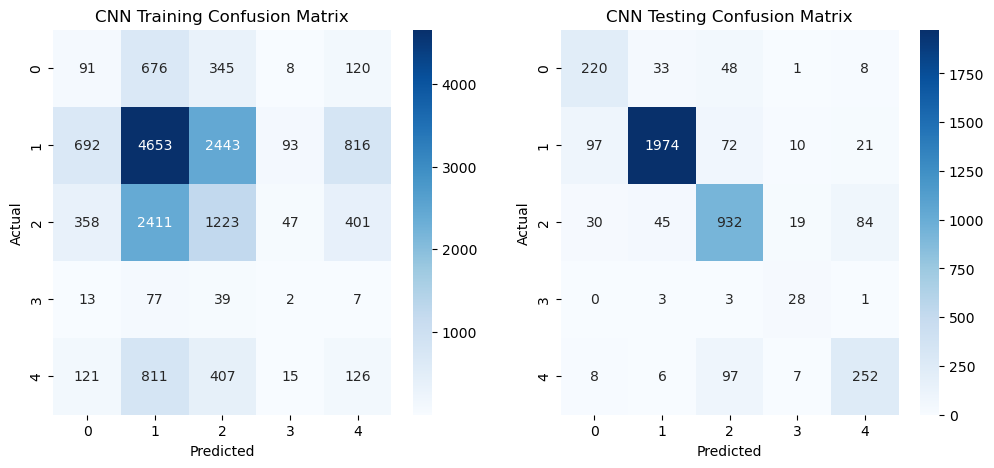

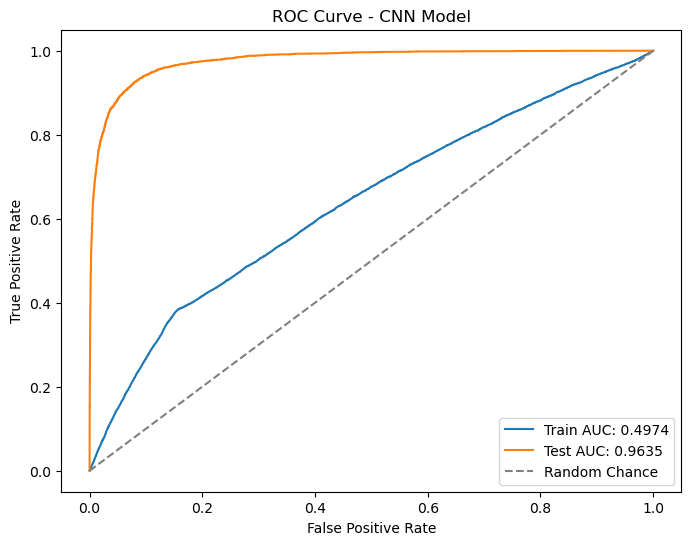

In [322]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Predict on Training & Test Set
cnn_model2.eval()
y_pred_train_c, y_prob_train_c = [], []
y_pred_test_c, y_prob_test_c = [], []

with torch.no_grad():
    # Training Predictions
    for images, labels in train_loader:
        images = images.to(device)
        outputs = cnn_model2(images)
        _, preds = torch.max(outputs, 1)
        probs = torch.nn.functional.softmax(outputs, dim=1)

        y_pred_train_c.extend(preds.cpu().numpy())
        y_prob_train_c.extend(probs.cpu().numpy())

    # Testing Predictions
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model2(images)
        _, preds = torch.max(outputs, 1)
        probs = torch.nn.functional.softmax(outputs, dim=1)

        y_pred_test_c.extend(preds.cpu().numpy())
        y_prob_test_c.extend(probs.cpu().numpy())

# Convert to NumPy
y_pred_train_c = np.array(y_pred_train_c)
y_prob_train_c = np.array(y_prob_train_c)
y_pred_test_c = np.array(y_pred_test_c)
y_prob_test_c = np.array(y_prob_test_c)

# Compute Metrics
accuracy_train_c = accuracy_score(y_train_c, y_pred_train_c)
f1_train_c = f1_score(y_train_c, y_pred_train_c, average="weighted")
accuracy_test_c = accuracy_score(y_test_c, y_pred_test_c)
f1_test_c = f1_score(y_test_c, y_pred_test_c, average="weighted")

# Ensure labels are binarized for AUC computation
y_train_binarized_c = label_binarize(y_train_c, classes=np.unique(y_train_c))
y_test_binarized_c = label_binarize(y_test_c, classes=np.unique(y_test_c))

auc_train_c = roc_auc_score(y_train_binarized_c, y_prob_train_c, multi_class="ovr") if y_train_binarized_c.shape[1] > 1 else np.nan
test_auc_c = roc_auc_score(y_test_binarized_c, y_prob_test_c, multi_class="ovr") if y_test_binarized_c.shape[1] > 1 else np.nan

print(f"\nCNN Model (Final Iteration) Metrics:")
print(f"Train Accuracy: {accuracy_train_c:.4f}, Train F1 Score: {f1_train_c:.4f}, Train AUC: {auc_train_c:.4f}")
print(f"Test Accuracy: {accuracy_test_c:.4f}, Test F1 Score: {f1_test_c:.4f}, Test AUC: {test_auc_c:.4f}")

# Compute Confusion Matrices
conf_matrix_train_c = confusion_matrix(y_train_c, y_pred_train_c)
conf_matrix_test_c = confusion_matrix(y_test_c, y_pred_test_c)

# Store for final plots
confusion_matrices["CNN_Train"] = conf_matrix_train_c
confusion_matrices["CNN_Test"] = conf_matrix_test_c

# Display Confusion Matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix_train_c, annot=True, fmt='d', cmap="Blues",
            xticklabels=np.unique(y_train_c), yticklabels=np.unique(y_train_c), ax=axs[0])
axs[0].set_title("CNN Training Confusion Matrix")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_test_c, annot=True, fmt='d', cmap="Blues",
            xticklabels=np.unique(y_test_c), yticklabels=np.unique(y_test_c), ax=axs[1])
axs[1].set_title("CNN Testing Confusion Matrix")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")

plt.show()

# Compute ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train_binarized_c.ravel(), y_prob_train_c.ravel())
fpr_test, tpr_test, _ = roc_curve(y_test_binarized_c.ravel(), y_prob_test_c.ravel())

# Plot AUC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train AUC: {auc_train_c:.4f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC: {test_auc_c:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Chance")  # Dotted reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN Model")
plt.legend()
plt.show()

In [339]:
import pandas as pd

# Ensure DataFrame exists
if "results_df" not in locals():
    results_df = pd.DataFrame(columns=["Model", "Set", "Accuracy", "F1 Score", "AUC", "Training Time"])

# Append CNN results for Training & Testing
new_rows = pd.DataFrame([
    {"Model": "CNN Final Iteration", "Set": "Training", "Accuracy": accuracy_train_c, "F1 Score": f1_train_c, "AUC": auc_train_c, "Training Time": training_time_cnn2},
    {"Model": "CNN Final Iteration", "Set": "Testing", "Accuracy": accuracy_test_c, "F1 Score": f1_test_c, "AUC": auc_test_c, "Training Time": training_time_cnn2}
])

results_df = pd.concat([results_df, new_rows], ignore_index=True)

print("\nCNN Training & Testing Results Stored")


CNN Training & Testing Results Stored


In [341]:
results_df

,Model,Set,Accuracy,F1 Score,AUC,Training Time
0,kNN,Training,1.000000,1.000000,1.000000,0.004009
1,kNN,Testing,0.580395,0.542812,0.661841,0.004009
2,SVM,Training,0.846400,0.830031,0.989228,315.144360
3,SVM,Testing,0.685921,0.643251,0.783853,315.144360
4,DNN Iteration 3,Training,0.683401,0.656727,0.834888,26.810000
5,DNN Iteration 3,Testing,0.626907,0.602295,0.764113,26.810000
6,CNN Final Iteration,Training,0.381057,0.382005,0.497403,296.750000
7,CNN Final Iteration,Testing,0.851713,0.855076,0.946855,296.750000


### References
1. ChatGpt
   Prompt: i want to use pytorch with cuda for computer vision for gpu acceleration, lets start then, we will be using jupyter and provide code one by one not everything at once:

    Model Evaluation 
    
    kNN Model with Confusion Matrix and AUC
    
    SVM Model with Confusion Matrix and AUC
    
    DNN Model with Confusion Matrix and AUC
    
    CNN Model with Confusion Matrix and AUC 
    
    Data Preprocessing - 15%
    
    Model Interpretability and Tuning - 20%
    
    Will subset YELP photo dataset for easy processing using 50000 images and store it first then start:
    
    Detailed Preprocessing including Intensity Thresholds, Histogram equalization and Gaussian Blur
    SVM no cross validation
    Really-well tuned KNN, cross validation performed
    Really-well tuned CNN, apt architecture to achieve strong performance, cross validation performed
    DNN with strong accuracy and recall, really well tuned, apt architecture for the dataset, cross validation performed
    
    At the end create a table to store training and testing results of each model metrics and training time, will share more when will reach at that point.